# Fraud Detection Project — Accredian Internship Task

## Problem Statement
The objective of this project is to build a **Fraud Detection System** using machine learning.
We are given a dataset that contains transaction details, and the task is to classify whether a 
transaction is fraudulent or not.

### Steps:
1. Load and understand the dataset.
2. Perform Exploratory Data Analysis (EDA).
3. Preprocess the data (handle missing values, encode, scale).
4. Train multiple ML models.
5. Evaluate performance using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
6. Select the best model and give business insights.


## Step 1: Loading the Dataset
We load `Fraud.csv` into a Pandas DataFrame, dropping the two identifier columns at
read time so the 471 MB file parses in about a second rather than half a minute.


In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization - all styling lives in viz_style.py at the repo root
import matplotlib.pyplot as plt
import viz_style as vs

vs.apply()

# Machine Learning
import gc
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu, chi2_contingency

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

SRC = ("Source: PaySim synthetic mobile-money transaction log (Fraud.csv) "
       "— 6,362,620 transactions over 31 simulated days")
CLASSES = ["Legitimate", "Fraudulent"]
# Fixed across every figure so the reader learns it once.
CLASS_COLORS = [vs.BLUE, vs.ORANGE]


In [2]:
# nameOrig / nameDest are per-transaction account identifiers with ~6.3M distinct
# values each. They are dropped at read time rather than after: skipping them and
# using the pyarrow engine takes this 471 MB read from ~30s to under two seconds.
USE = ["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
       "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]

data = pd.read_csv("Fraud.csv", engine="pyarrow", usecols=USE)

n_total = len(data)
n_fraud = int(data["isFraud"].sum())
fraud_rate = 100 * n_fraud / n_total
print(f"{n_total:,} transactions, {n_fraud:,} fraudulent ({fraud_rate:.3f}%)")
data.head()


6,362,620 transactions, 8,213 fraudulent (0.129%)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


## Step 2: Exploratory Data Analysis (EDA)

In this step, we explore the dataset to better understand its structure, balance, and key relationships.  
We cover the following analyses:

- **2.1** Dataset size (rows & columns), column types, and missing values  
- **2.2** Fraud distribution (`isFraud`)  
- **2.3** Transaction type distribution  
- **2.4** Fraud counts across transaction types  
- **2.5** Fraud proportion (%) per transaction type  
- **2.6** Transaction amount distribution (fraud vs non-fraud)  
- **2.7** Correlation heatmap of numerical features  
- **2.8** Log-transformed transaction amount distributions (density comparison)  
- **2.9** Boxplot of Old Balance Origin vs Fraud   
- **2.10** Boxplot of Old Balance Destination vs Fraud
- **2.11** Scatterplots of balance difference vs transaction amount (log-scaled), split by fraud vs non-fraud  
- **2.12** Chi-Square test for transaction type vs fraud  
- **2.13** Mann–Whitney U-Test for transaction amount  

### 2.1 Check Dataset Shape, Column Types, and Missing Values
Understanding dataset structure, feature data types, and checking for missing values.

In [3]:
print("Shape of dataset:", data.shape)
print("\nData Types:\n", data.dtypes)
print("\nMissing values:\n", data.isnull().sum())

# Quick statistical summary
data.describe()


Shape of dataset: (6362620, 9)

Data Types:
 step                int64
type               object
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object



Missing values:


 step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### 2.2 Fraud Distribution
Visualizing the class imbalance between fraudulent and non-fraudulent transactions.

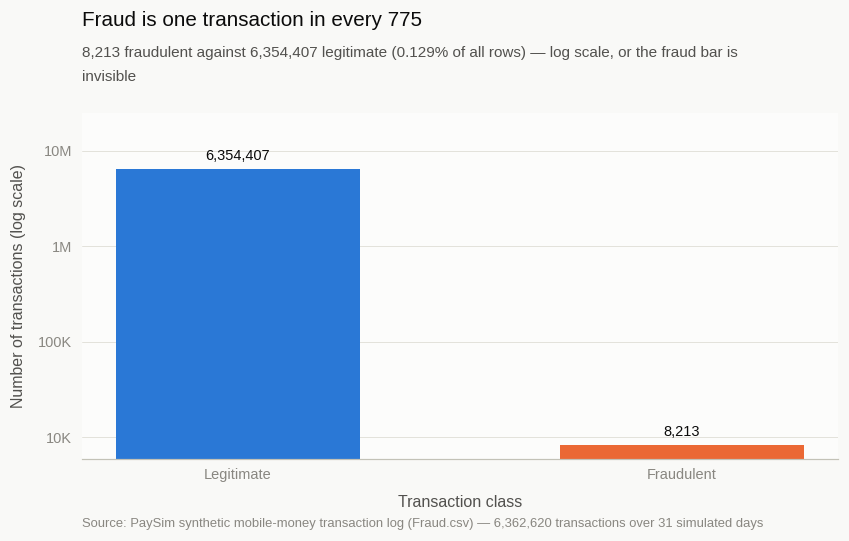

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [4]:
counts = data["isFraud"].value_counts().sort_index()

fig, ax = vs.figure()
ax.bar(CLASSES, counts.values, color=CLASS_COLORS, width=0.55)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(vs.fmt_log_compact())
vs.headroom(ax, 0.14, log=True)
for i, v in enumerate(counts.values):
    vs.label_bar(ax, i, v, f"{v:,}")

vs.finish(
    fig, ax,
    title="Fraud is one transaction in every 775",
    subtitle=f"{n_fraud:,} fraudulent against {n_total - n_fraud:,} legitimate "
             f"({fraud_rate:.3f}% of all rows) — log scale, or the fraud bar is invisible",
    xlabel="Transaction class",
    ylabel="Number of transactions (log scale)",
    source=SRC,
)
vs.save(fig, "01-class-imbalance")
plt.show()

print(data["isFraud"].value_counts(normalize=True) * 100)


The target variable **`isFraud`** is extremely imbalanced:

- **0 → Non-Fraud (~99.87%)**
- **1 → Fraud (~0.13%)**

This confirms that fraud detection is a **rare event classification problem**, where normal transactions heavily outnumber fraudulent ones.  
Special techniques (resampling, anomaly detection, or using imbalance-aware algorithms) will be needed when building the model.


We first check the distribution of transaction types (e.g., `CASH_IN`, `CASH_OUT`, `TRANSFER`, etc.).  
This helps us understand which types are most common and if fraud is more likely in specific categories.


### 2.3 Transaction Types Distribution
Analyzing the frequency of different transaction types in the dataset

Transaction Types:
 type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


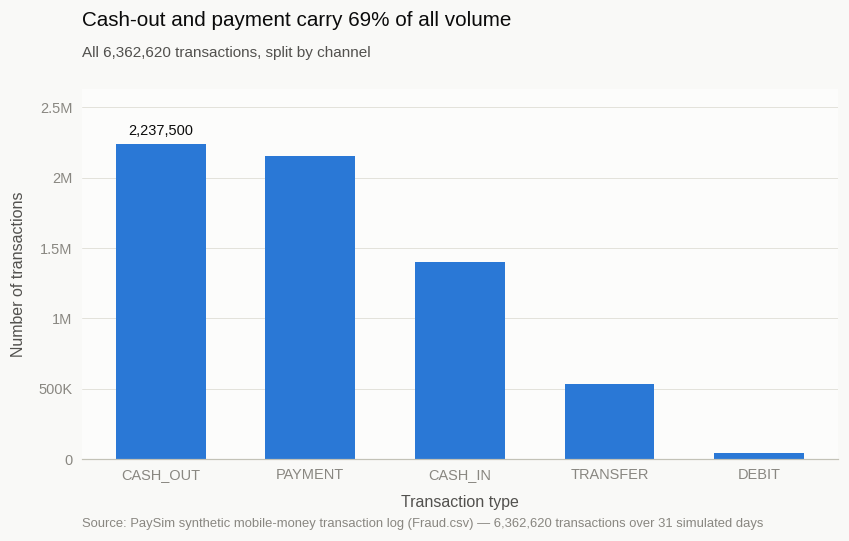

In [5]:
type_counts = data["type"].value_counts()
print("Transaction Types:\n", type_counts)

fig, ax = vs.figure()
ax.bar(type_counts.index, type_counts.values, color=vs.BLUE, width=0.6)
ax.yaxis.set_major_formatter(vs.fmt_compact())
vs.headroom(ax, 0.12)
vs.label_bar(ax, 0, type_counts.values[0], f"{type_counts.values[0]:,}")

vs.finish(
    fig, ax,
    title="Cash-out and payment carry 69% of all volume",
    subtitle=f"All {n_total:,} transactions, split by channel",
    xlabel="Transaction type",
    ylabel="Number of transactions",
    source=SRC,
)
vs.save(fig, "02-transaction-type-mix")
plt.show()


### 2.4 Fraud Distribution across Transaction Types
Fraud is not equally distributed across transaction types, indicating potential behavioral patterns.

Fraud counts by transaction type:
 type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64


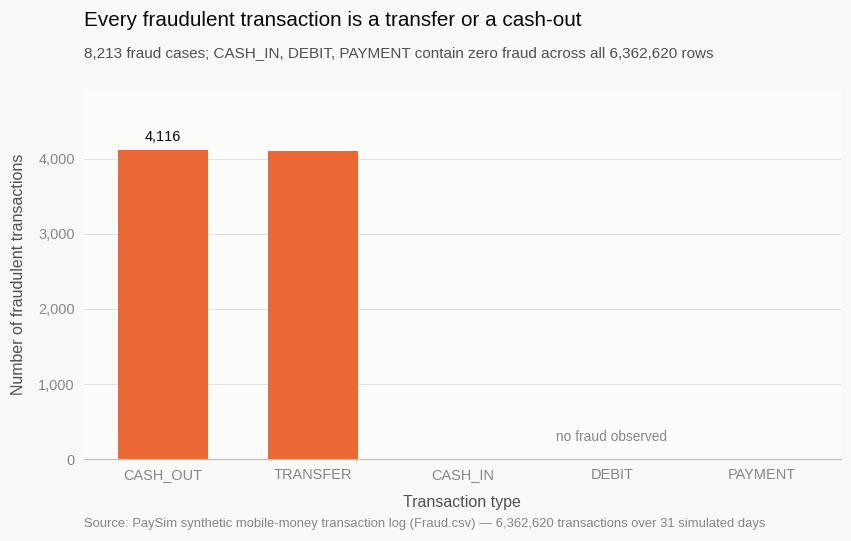

In [6]:
fraud_by_type = data.groupby("type")["isFraud"].sum().sort_values(ascending=False)
print("Fraud counts by transaction type:\n", fraud_by_type)

zero_types = [t for t in fraud_by_type.index if fraud_by_type[t] == 0]

fig, ax = vs.figure()
ax.bar(fraud_by_type.index, fraud_by_type.values, color=vs.ORANGE, width=0.6)
ax.yaxis.set_major_formatter(vs.fmt_thousands())
vs.headroom(ax, 0.14)
vs.label_bar(ax, 0, fraud_by_type.values[0], f"{fraud_by_type.values[0]:,}")
ax.annotate("no fraud observed", (3, 0), textcoords="offset points",
            xytext=(0, 12), ha="center", fontsize=9, color=vs.MUTED)

vs.finish(
    fig, ax,
    title="Every fraudulent transaction is a transfer or a cash-out",
    subtitle=f"{n_fraud:,} fraud cases; {', '.join(zero_types)} contain zero fraud "
             f"across all {n_total:,} rows",
    xlabel="Transaction type",
    ylabel="Number of fraudulent transactions",
    source=SRC,
)
vs.save(fig, "03-fraud-count-by-type")
plt.show()


Fraud is not merely concentrated in certain channels — it is **exclusive** to two of
them. `CASH_OUT` and `TRANSFER` account for all 8,213 fraud cases; `PAYMENT`, `DEBIT`
and `CASH_IN` contain not a single one across 3.6M rows. Any model can therefore
discard three of the five channels outright.


### 2.5 Fraud Proportion per Transaction Type
Calculating and visualizing the proportion of fraud for each transaction type.

Fraud proportion (%) by transaction type:
 type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


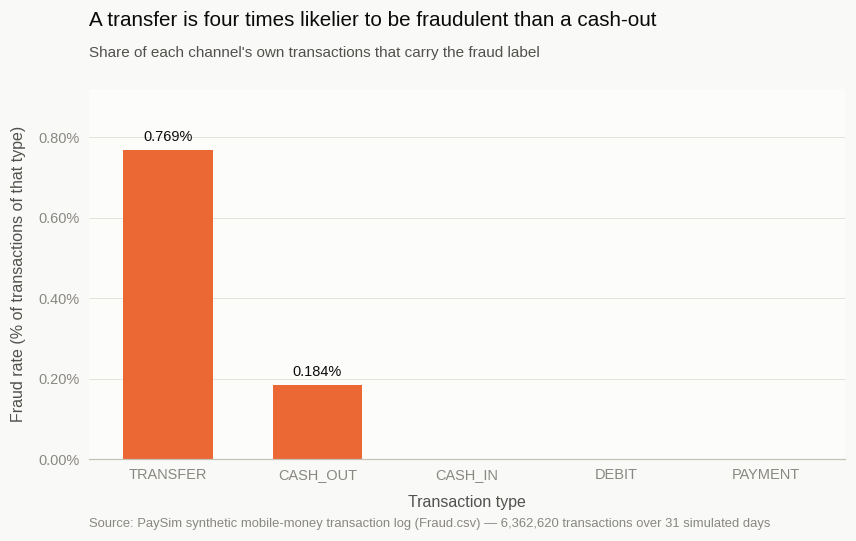

In [7]:
fraud_rate_by_type = (data.groupby("type")["isFraud"].mean() * 100).sort_values(ascending=False)
print("Fraud proportion (%) by transaction type:\n", fraud_rate_by_type)

fig, ax = vs.figure()
ax.bar(fraud_rate_by_type.index, fraud_rate_by_type.values, color=vs.ORANGE, width=0.6)
ax.yaxis.set_major_formatter(vs.fmt_percent(2))
vs.headroom(ax, 0.14)
vs.label_bar(ax, 0, fraud_rate_by_type.values[0], f"{fraud_rate_by_type.values[0]:.3f}%")
vs.label_bar(ax, 1, fraud_rate_by_type.values[1], f"{fraud_rate_by_type.values[1]:.3f}%")

vs.finish(
    fig, ax,
    title="A transfer is four times likelier to be fraudulent than a cash-out",
    subtitle="Share of each channel's own transactions that carry the fraud label",
    xlabel="Transaction type",
    ylabel="Fraud rate (% of transactions of that type)",
    source=SRC,
)
vs.save(fig, "04-fraud-rate-by-type")
plt.show()


### 2.6 Transaction Amount Distribution (Fraud vs Non-Fraud)
Comparing how transaction amounts vary between fraudulent and legitimate transactions.

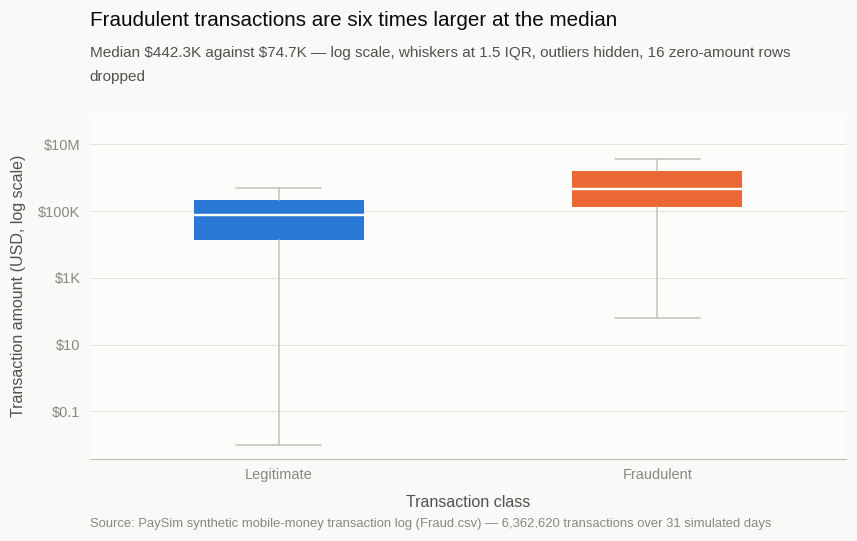

In [8]:
# 16 fraudulent rows have amount == 0 and are dropped so the axis can be log-scaled.
positive = data[data["amount"] > 0]
medians = positive.groupby("isFraud")["amount"].median()

fig, ax = vs.figure()
vs.boxes(ax,
         [positive.loc[positive.isFraud == 0, "amount"].values,
          positive.loc[positive.isFraud == 1, "amount"].values],
         CLASSES, CLASS_COLORS)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(vs.fmt_currency())
vs.headroom(ax, 0.10, log=True)

vs.finish(
    fig, ax,
    title="Fraudulent transactions are six times larger at the median",
    subtitle=f"Median {vs._compact(medians[1], True)} against {vs._compact(medians[0], True)} "
             f"— log scale, whiskers at 1.5 IQR, outliers hidden, 16 zero-amount rows dropped",
    xlabel="Transaction class",
    ylabel="Transaction amount (USD, log scale)",
    source=SRC,
)
vs.save(fig, "05-amount-by-class")
plt.show()


### 2.7 Correlation Heatmap of Numerical Features
Checking correlations among key numerical variables to detect potential relationships.

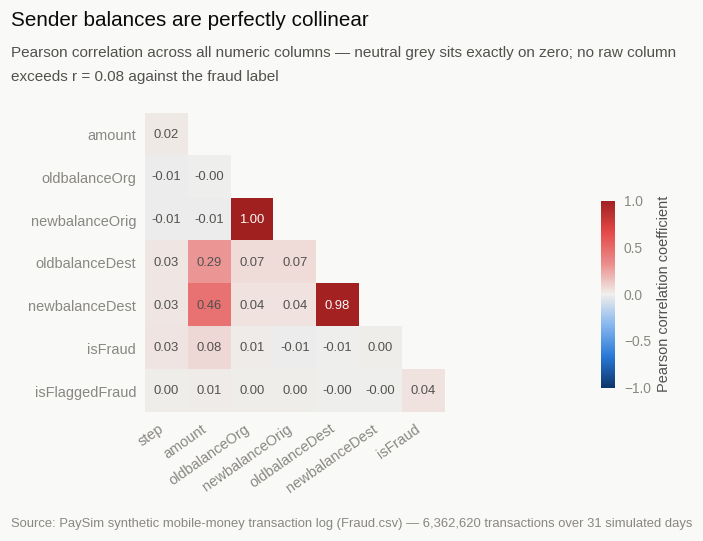

In [9]:
corr = data.corr(numeric_only=True)

# The 1.00 diagonal is not information and the matrix is symmetric, so the
# diagonal and upper triangle are masked out as redundant ink.
mask = np.triu(np.ones_like(corr.values, dtype=bool))
masked = np.ma.masked_where(mask, corr.values)

fig, ax = vs.figure()
cmap = vs.CMAP_DIV.copy()
cmap.set_bad(vs.PAGE)
im = ax.imshow(masked, cmap=cmap, norm=vs.diverging_norm(-1, 1))
ax.set_xticks(range(len(corr) - 1), corr.columns[:-1], rotation=35, ha="right")
ax.set_yticks(range(1, len(corr)), corr.columns[1:])
ax.set_xlim(-0.5, len(corr) - 1.5)
ax.set_ylim(len(corr) - 0.5, 0.5)
ax.grid(False)
ax.spines["bottom"].set_visible(False)
for i in range(len(corr)):
    for j in range(i):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color=vs.SURFACE if abs(v) > 0.6 else vs.INK_2)

vs.finish(
    fig, ax,
    title="Sender balances are perfectly collinear",
    subtitle="Pearson correlation across all numeric columns — neutral grey sits exactly "
             "on zero; no raw column exceeds r = 0.08 against the fraud label",
    xlabel="", ylabel="", source=SRC,
    left=0.185, right=0.83, bottom=0.235,
)
cax = fig.add_axes([0.855, 0.28, 0.016, 0.34])
cb = fig.colorbar(im, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=9, colors=vs.MUTED, length=0)
cb.set_label("Pearson correlation coefficient", fontsize=9.5, color=vs.INK_2)

vs.save(fig, "06-correlation-heatmap")
plt.show()


### Handling Multicollinearity

We observed very high correlations between the balance-related variables:

- `oldbalanceOrg` and `newbalanceOrig` → correlation ≈ **1.0**  
- `oldbalanceDest` and `newbalanceDest` → correlation ≈ **0.98**

#### Why we drop only `newbalanceOrig`:
- Since the correlation between `oldbalanceOrg` and `newbalanceOrig` is essentially **perfect (1.0)**, keeping both introduces redundancy and multicollinearity issues.
- We choose to keep `oldbalanceOrg` and drop `newbalanceOrig` because the **original balance before transaction** is more fundamental and interpretable.

#### Why we keep both destination balances:
- Although the correlation between `oldbalanceDest` and `newbalanceDest` is also very high (~0.98), it is **not perfectly 1.0**.  
- Fraudulent activity might create **anomalies in the destination balances** (e.g., balance not updated as expected, inconsistencies between old and new).  
- Dropping one could remove valuable signals of such anomalies.

**Decision:**  
- Drop `newbalanceOrig` (perfect redundancy).  
- Keep both `oldbalanceDest` and `newbalanceDest` (retain potential fraud signals).


### 2.8 Log-Transform Transaction Amounts (Density Comparison)
Applying log transformation to transaction amounts for better distribution visualization.

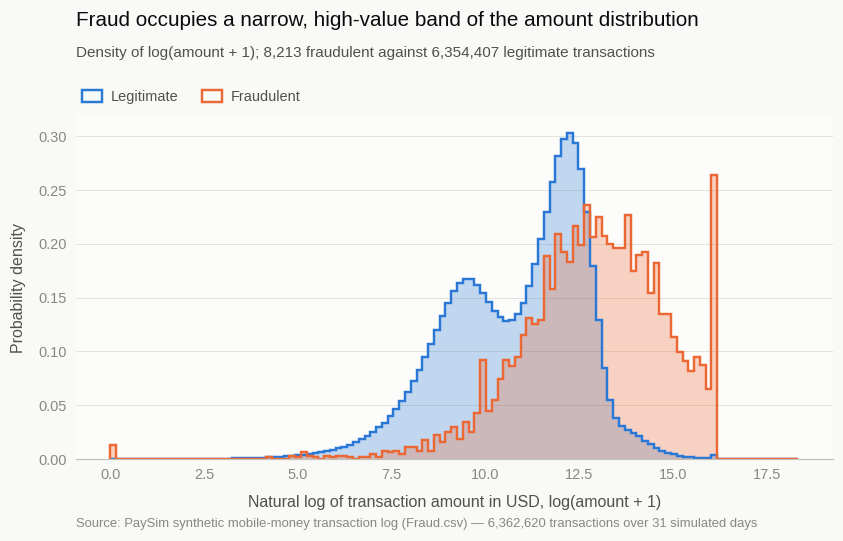

In [10]:
fig, ax = vs.figure()
bins = np.linspace(0, np.log1p(data["amount"].max()), 120)
for cls, colour, label in ((0, vs.BLUE, "Legitimate"), (1, vs.ORANGE, "Fraudulent")):
    values = np.log1p(data.loc[data["isFraud"] == cls, "amount"])
    ax.hist(values, bins=bins, density=True, color=colour, alpha=0.28)
    ax.hist(values, bins=bins, density=True, histtype="step", color=colour,
            linewidth=1.6, label=label)

vs.finish(
    fig, ax,
    title="Fraud occupies a narrow, high-value band of the amount distribution",
    subtitle=f"Density of log(amount + 1); {n_fraud:,} fraudulent against "
             f"{n_total - n_fraud:,} legitimate transactions",
    xlabel="Natural log of transaction amount in USD, log(amount + 1)",
    ylabel="Probability density",
    source=SRC, legend=True,
)
vs.save(fig, "07-amount-distribution-log")
plt.show()


### 2.9 Boxplot of Old Balance Origin vs Fraud
Examining how sender’s old balance differs between fraudulent and non-fraudulent transactions.

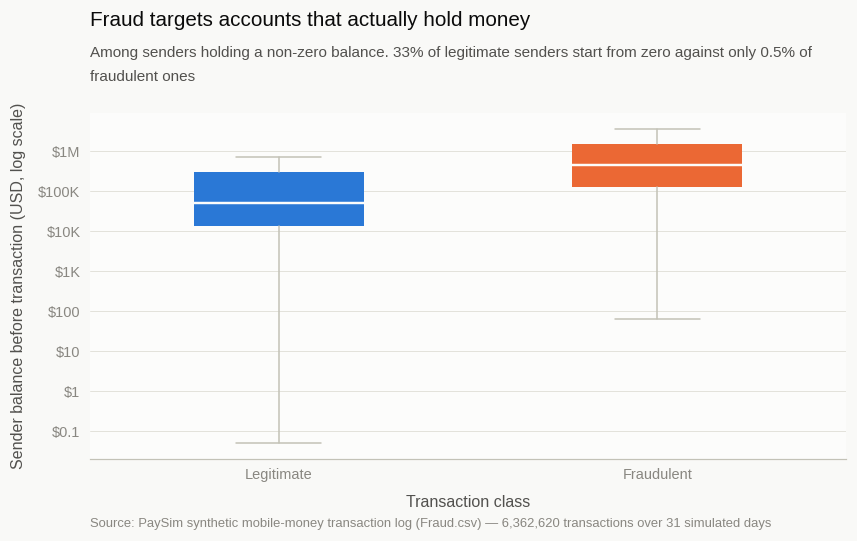

In [11]:
def balance_boxplot(column, ylabel, title, subtitle, filename):
    """Compare a balance column across classes, restricted to non-zero balances.

    A third to two thirds of each class sits at exactly zero. On a log axis that
    mass collapses the box into a solid slab and hides the distribution being
    compared, so the zero shares are reported in the subtitle instead.
    """
    nz = data[data[column] > 0]
    fig, ax = vs.figure()
    vs.boxes(ax,
             [nz.loc[nz.isFraud == 0, column].values,
              nz.loc[nz.isFraud == 1, column].values],
             CLASSES, CLASS_COLORS)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(vs.fmt_currency())
    vs.finish(fig, ax, title=title, subtitle=subtitle,
              xlabel="Transaction class", ylabel=ylabel, source=SRC)
    vs.save(fig, filename)
    plt.show()


zero_legit = (data.loc[data.isFraud == 0, "oldbalanceOrg"] == 0).mean() * 100
zero_fraud = (data.loc[data.isFraud == 1, "oldbalanceOrg"] == 0).mean() * 100

balance_boxplot(
    "oldbalanceOrg",
    "Sender balance before transaction (USD, log scale)",
    "Fraud targets accounts that actually hold money",
    f"Among senders holding a non-zero balance. {zero_legit:.0f}% of legitimate senders "
    f"start from zero against only {zero_fraud:.1f}% of fraudulent ones",
    "08-origin-balance-by-class",
)


### 2.10 Boxplot of Old Balance Destination vs Fraud
Examining how receiver’s old balance differs between fraudulent and non-fraudulent transactions.

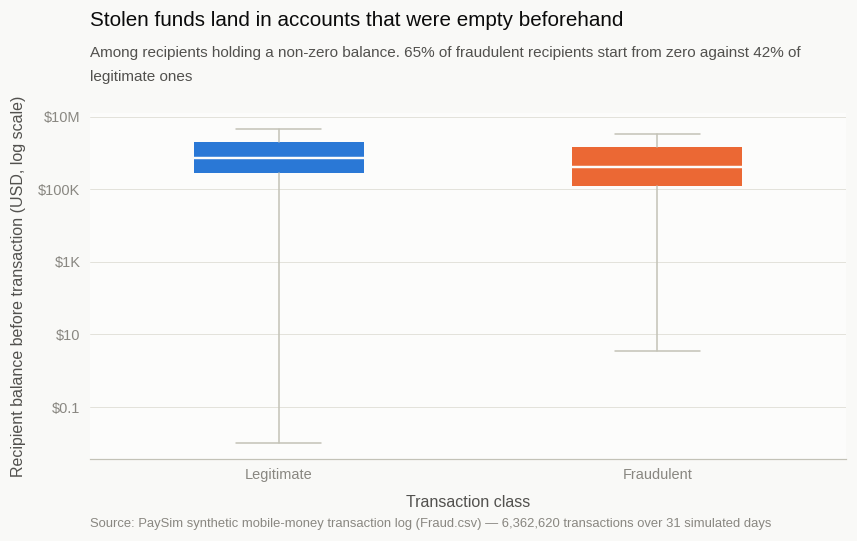

In [12]:
zero_dest_legit = (data.loc[data.isFraud == 0, "oldbalanceDest"] == 0).mean() * 100
zero_dest_fraud = (data.loc[data.isFraud == 1, "oldbalanceDest"] == 0).mean() * 100

balance_boxplot(
    "oldbalanceDest",
    "Recipient balance before transaction (USD, log scale)",
    "Stolen funds land in accounts that were empty beforehand",
    f"Among recipients holding a non-zero balance. {zero_dest_fraud:.0f}% of fraudulent "
    f"recipients start from zero against {zero_dest_legit:.0f}% of legitimate ones",
    "09-destination-balance-by-class",
)


### 2.11 Fraud Rate by Hour of Day
`step` counts hours since the start of the simulation, so `step % 24` recovers the
hour of day. This is the single strongest pattern in the dataset.


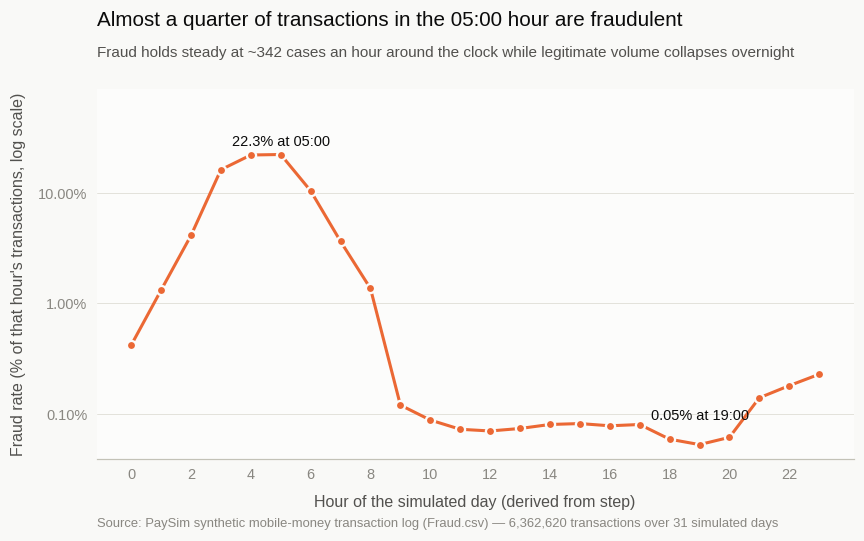

           n  fraud       rate
hour                          
19    647814    342   0.052793
5       1641    366  22.303473


In [13]:
data["hour"] = data["step"] % 24
hourly = data.groupby("hour").agg(n=("isFraud", "size"), fraud=("isFraud", "sum"))
hourly["rate"] = 100 * hourly["fraud"] / hourly["n"]

peak, trough = hourly["rate"].idxmax(), hourly["rate"].idxmin()

fig, ax = vs.figure()
ax.plot(hourly.index, hourly["rate"].values, color=vs.ORANGE, linewidth=2.0,
        marker="o", markersize=6, markerfacecolor=vs.ORANGE,
        markeredgecolor=vs.SURFACE, markeredgewidth=1.5)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(vs.fmt_percent(2))
ax.set_xticks(range(0, 24, 2))
vs.headroom(ax, 0.16, log=True)
vs.label_bar(ax, peak, hourly["rate"][peak], f"{hourly['rate'][peak]:.1f}% at {peak:02d}:00")
vs.label_bar(ax, trough, hourly["rate"][trough],
             f"{hourly['rate'][trough]:.2f}% at {trough:02d}:00", dy=10)

vs.finish(
    fig, ax,
    title="Almost a quarter of transactions in the 05:00 hour are fraudulent",
    subtitle=f"Fraud holds steady at ~{hourly['fraud'].mean():.0f} cases an hour around "
             f"the clock while legitimate volume collapses overnight",
    xlabel="Hour of the simulated day (derived from step)",
    ylabel="Fraud rate (% of that hour's transactions, log scale)",
    source=SRC,
)
vs.save(fig, "10-fraud-rate-by-hour")
plt.show()

print(hourly.loc[[trough, peak]])


### 2.12 The Balance-Update Signature
A transaction that moves money out of a sender but leaves the recipient's balance
untouched is an accounting impossibility in a real ledger. It is also the single
most useful engineered feature in the model that follows.


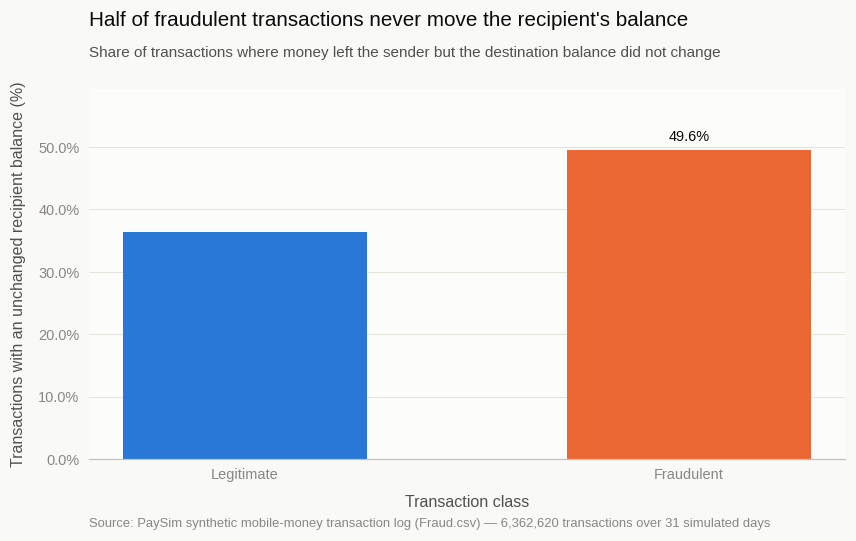

isFraud
0    36.403177
1    49.555583
Name: dest_unchanged, dtype: float64


In [14]:
data["dest_unchanged"] = (
    (data["amount"] > 0) & (data["newbalanceDest"] == data["oldbalanceDest"])
)
unchanged = data.groupby("isFraud")["dest_unchanged"].mean() * 100

fig, ax = vs.figure()
ax.bar(CLASSES, unchanged.values, color=CLASS_COLORS, width=0.55)
ax.yaxis.set_major_formatter(vs.fmt_percent(1))
vs.headroom(ax, 0.14)
vs.label_bar(ax, 1, unchanged.values[1], f"{unchanged.values[1]:.1f}%")

vs.finish(
    fig, ax,
    title="Half of fraudulent transactions never move the recipient's balance",
    subtitle="Share of transactions where money left the sender but the destination "
             "balance did not change",
    xlabel="Transaction class",
    ylabel="Transactions with an unchanged recipient balance (%)",
    source=SRC,
)
vs.save(fig, "11-balance-error-signature")
plt.show()

print(unchanged)


## 2.13 Statistical Analysis of Fraud vs Non-Fraud Transactions

In [15]:
data.groupby("isFraud")["amount"].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00



We analyzed the transaction amounts for fraudulent (`isFraud=1`) and non-fraudulent (`isFraud=0`) cases.  
Below is the summary of key descriptive statistics:

| Metric        | Non-Fraud (`isFraud=0`) | Fraud (`isFraud=1`) |
|---------------|--------------------------|----------------------|
| Count         | 6,354,407               | 8,213                |
| Mean          | 178,197                 | 1,467,967            |
| Std. Dev.     | 596,237                 | 2,404,253            |
| Min           | 0.01                    | 0.00                 |
| 25% (Q1)      | 13,368                  | 127,091              |
| Median (Q2)   | 74,684                  | 441,423              |
| 75% (Q3)      | 208,365                 | 1,517,771            |
| Max           | 92,445,517              | 10,000,000           |

### Key Insights:
1. **Fraud transactions are much larger in value.**
   - The average fraud amount (~1.47M) is almost **8x higher** than the average non-fraud (~178K).
   - The median fraud transaction (441K) is about **6x larger** than the median non-fraud (75K).

2. **Higher variability in fraud.**
   - Fraud amounts have a much higher standard deviation (2.4M) compared to non-fraud (596K), showing more inconsistency in fraud behavior.

3. **Different distributional ranges.**
   - 75% of non-fraud transactions are under ~208K, whereas 75% of frauds are below ~1.5M.
   - Fraudulent transactions tend to cluster in higher ranges.

4. **Maximum values are different in scale.**
   - Non-fraud transactions go as high as ~92M.
   - Fraudulent transactions cap at 10M (suggesting potential business rule or system-imposed upper limit).

---

### Interpretation
- Fraudsters prefer **high-value transfers** (likely to maximize gains per attempt).
- Fraudulent behavior shows **distinct transaction size patterns**, which could be leveraged as strong predictive features.
- These statistics suggest focusing on **transaction amount thresholds** (combined with type, origin, destination) in fraud detection models.


### 2.14 Chi-Square Test for Transaction Type vs Fraud
Testing whether fraud occurrence is independent of transaction type.


In [16]:
contingency = pd.crosstab(data["type"], data["isFraud"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:,.1f}  (dof {dof})")
print(f"Chi-square test p-value: {p:.4e}")


Chi-square statistic: 22,082.5  (dof 4)
Chi-square test p-value: 0.0000e+00


### 2.15 Mann–Whitney U-Test for Transaction Amount
Statistical test to compare transaction amount distributions between fraud and
non-fraud cases.


In [17]:
fraud_amount = data.loc[data["isFraud"] == 1, "amount"]
nonfraud_amount = data.loc[data["isFraud"] == 0, "amount"]
stat, p = mannwhitneyu(fraud_amount, nonfraud_amount, alternative="two-sided")
print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"Mann-Whitney U-test p-value: {p:.4e}")


Mann-Whitney U statistic: 41,224,999,611
Mann-Whitney U-test p-value: 0.0000e+00


## Statistical Significance in Fraud Detection

During EDA, we performed statistical tests to validate whether differences between fraud and non-fraud transactions are significant.

**1. Chi-Square Test: Transaction Type vs Fraud**  
- **Purpose:** Check if fraud occurrence depends on transaction type.  
- **Result:** p-value ≈ 0.0000  
- **Interpretation:** Fraud is highly associated with certain transaction types (mainly `CASH_OUT` and `TRANSFER`).  

**2. Mann–Whitney U-Test: Transaction Amount**  
- **Purpose:** Compare transaction amounts between fraud and non-fraud cases.  
- **Result:** p-value ≈ 0.0000  
- **Interpretation:** Fraudulent transactions have significantly different amounts compared to normal transactions.  

**Key Takeaways:**  
- Statistically significant results confirm visual EDA insights.  
- Certain transaction types and amounts are strong indicators of fraud.  
- These insights guide feature selection and engineering for ML models.


## Step 3: Data Preprocessing

In this step, we prepare the dataset for modeling by cleaning, transforming, and engineering features.  
We design the preprocessing as a modular pipeline so it can be reused on future datasets.

- Encode Categorical Variables (One-Hot Encoding of type)
- Drop Irrelevant Columns (nameOrig, nameDest, isFlaggedFraud)
- Transaction Type Handling (flag always_nonfraud_type)
- Feature Transformations (log-transform skewed features like amount)
- Create New Features (balance differences, suspicious & error flags)
- Engineer Time-Based Features (from step: hour, day_of_week, cyclical encoding)
- Scale Numerical Features (normalize values with StandardScaler)


In [18]:
data.isnull().sum()


step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
hour              0
dest_unchanged    0
dtype: int64

In [19]:
class FraudPreprocessor(BaseEstimator, TransformerMixin):
    """Feature engineering for the PaySim fraud data.

    Note on `fit`: an earlier version dropped PAYMENT / DEBIT / CASH_IN rows
    before fitting the encoder and the scaler, while `transform` kept them. That
    left the one-hot encoder knowing only two of the five channels, so the three
    dropped ones silently encoded as all-zeros and `always_nonfraud_type` — which
    is derived from those very columns — was identically 0 for every row. `fit`
    and `transform` now see the same distribution.
    """

    def __init__(self, log_transform=True):
        self.log_transform = log_transform
        self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        self.scaler = StandardScaler()
        self.numeric_features = [
            "amount", "oldbalanceOrg", "oldbalanceDest", "newbalanceDest"
        ]  # removed 'newbalanceOrig'
        self.categorical_features = ["type"]

    def fit(self, X, y=None):
        X_ = X.copy()

        # Fit encoder on transaction type
        self.ohe.fit(X_[['type']])

        # Fit scaler on numeric features
        self.scaler.fit(X_[self.numeric_features])
        return self

    def transform(self, X):
        X_ = X.copy()

        # --- Engineered balance features BEFORE dropping ---
        if 'newbalanceOrig' in X_.columns:
            X_['diff_orig'] = X_['oldbalanceOrg'] - X_['newbalanceOrig']
        else:
            X_['diff_orig'] = 0
        X_['diff_dest'] = X_['newbalanceDest'] - X_['oldbalanceDest']

        # --- Drop identifiers + leakage + redundant col ---
        X_.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud', 'newbalanceOrig'],
                inplace=True, errors='ignore')

        # --- Time-based features from 'step' ---
        if 'step' in X_.columns:
            X_['hour'] = X_['step'] % 24
            X_['day_of_week'] = X_['step'] % 168
            # Cyclical encoding
            X_['hour_sin'] = np.sin(2 * np.pi * X_['hour'] / 24)
            X_['hour_cos'] = np.cos(2 * np.pi * X_['hour'] / 24)

        # --- One-hot encode transaction type ---
        type_encoded = self.ohe.transform(X_[['type']])
        type_encoded = pd.DataFrame(
            type_encoded,
            columns=self.ohe.get_feature_names_out(['type']),
            index=X_.index
        )
        X_ = pd.concat([X_.drop(columns=['type']), type_encoded], axis=1)

        # --- Always non-fraud type flag ---
        always_safe_types = ['PAYMENT', 'DEBIT', 'CASH_IN']
        X_['always_nonfraud_type'] = X_[type_encoded.columns].filter(
            regex="|".join(always_safe_types), axis=1
        ).sum(axis=1).clip(upper=1)

        # --- Log transform ---
        if self.log_transform and 'amount' in X_.columns:
            X_['log_amount'] = np.log1p(X_['amount'])

        # suspicious if money transferred but dest balance unchanged
        X_['suspicious_flag'] = (
            (X_['amount'] > 0) & (X_['newbalanceDest'] == X_['oldbalanceDest'])
        ).astype(int)

        # error flag for invalid balances
        X_['error_flag'] = (
            (X_['oldbalanceOrg'] < 0) |
            (X_['oldbalanceDest'] < 0) |
            (X_['newbalanceDest'] < 0)
        ).astype(int)

        # --- Scale numeric features ---
        X_[self.numeric_features] = self.scaler.transform(X_[self.numeric_features])

        return X_


In [20]:
# The EDA sections above added `hour` and `dest_unchanged` to `data` for plotting.
# They must not reach the model: FraudPreprocessor derives `hour` itself, and
# `dest_unchanged` is by construction identical to the engineered `suspicious_flag`,
# so leaving it in would hand the model the same column twice.
RAW_COLUMNS = ["step", "type", "amount", "oldbalanceOrg", "newbalanceOrig",
               "oldbalanceDest", "newbalanceDest", "isFlaggedFraud"]

y = data["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    data[RAW_COLUMNS], y,
    test_size=0.2, random_state=42, stratify=y
)

pre = FraudPreprocessor()
pre.fit(X_train)

# float32 halves the memory of a 5.1M x 20 design matrix and costs no accuracy here.
X_train_processed = pre.transform(X_train).astype(np.float32)
X_test_processed = pre.transform(X_test).astype(np.float32)
del X_train, X_test
gc.collect()

FEATURES = list(X_train_processed.columns)
print("Train shape:", X_train_processed.shape)
print("Test shape: ", X_test_processed.shape)
print("Features:   ", FEATURES)

joblib.dump(pre, "fraud_preprocessor.pkl")


Train shape: (5090096, 20)
Test shape:  (1272524, 20)
Features:    ['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'newbalanceDest', 'diff_orig', 'diff_dest', 'hour', 'day_of_week', 'hour_sin', 'hour_cos', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'always_nonfraud_type', 'log_amount', 'suspicious_flag', 'error_flag']


['fraud_preprocessor.pkl']

## Step 4: Model Evaluation

Three logistic-regression variants are compared, all with `class_weight="balanced"`:
an **amount-only** baseline that shows how far a single feature gets you, the **full
engineered** feature set, and a **reduced** set with the weak and constant features
removed. They are scored on the held-out 20% test split.


In [21]:
def fit_logistic(columns, name):
    """Scale, fit, score, then free the design matrices before the next model."""
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_processed[columns])
    X_te = scaler.transform(X_test_processed[columns])

    model = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
    model.fit(X_tr, y_train)
    prob = model.predict_proba(X_te)[:, 1]

    print(f"\n==== {name} ====")
    print(classification_report(y_test, (prob >= 0.5).astype(int), digits=4))

    coefficients = pd.Series(model.coef_[0], index=columns)
    del X_tr, X_te, model, scaler
    gc.collect()
    return prob, coefficients


# Dropped from the reduced model: weak or provably constant features. error_flag
# is identically 0 here - the data contains no negative balances at all.
DROP_FEATURES = ["oldbalanceDest", "always_nonfraud_type", "day_of_week",
                 "newbalanceDest", "amount", "hour", "error_flag"]
REDUCED = [c for c in FEATURES if c not in DROP_FEATURES]

VARIANTS = [
    ("Amount only", ["log_amount"]),
    ("All engineered features", FEATURES),
    ("Reduced feature set", REDUCED),
]

PROBS, COEFS = {}, {}
for name, columns in VARIANTS:
    PROBS[name], COEFS[name] = fit_logistic(columns, name)

MODEL_COLORS = {"Amount only": vs.AQUA,
                "All engineered features": vs.BLUE,
                "Reduced feature set": vs.ORANGE}
MSRC = (f"Source: PaySim (Fraud.csv) — held-out 20% test split, {len(y_test):,} "
        f"transactions, {int(y_test.sum()):,} fraudulent")



==== Amount only ====
              precision    recall  f1-score   support

           0     0.9995    0.6547    0.7911   1270881
           1     0.0027    0.7243    0.0054      1643

    accuracy                         0.6548   1272524
   macro avg     0.5011    0.6895    0.3983   1272524
weighted avg     0.9982    0.6548    0.7901   1272524




==== All engineered features ====
              precision    recall  f1-score   support

           0     0.9999    0.9680    0.9837   1270881
           1     0.0371    0.9537    0.0715      1643

    accuracy                         0.9680   1272524
   macro avg     0.5185    0.9609    0.5276   1272524
weighted avg     0.9987    0.9680    0.9825   1272524




==== Reduced feature set ====
              precision    recall  f1-score   support

           0     0.9999    0.9670    0.9832   1270881
           1     0.0361    0.9556    0.0696      1643

    accuracy                         0.9670   1272524
   macro avg     0.5180    0.9613    0.5264   1272524
weighted avg     0.9987    0.9670    0.9820   1272524



### 4.1 ROC Curves
ROC-AUC is the metric this problem is most often reported with, and it is close to
useless here — see the precision-recall chart directly below for why.


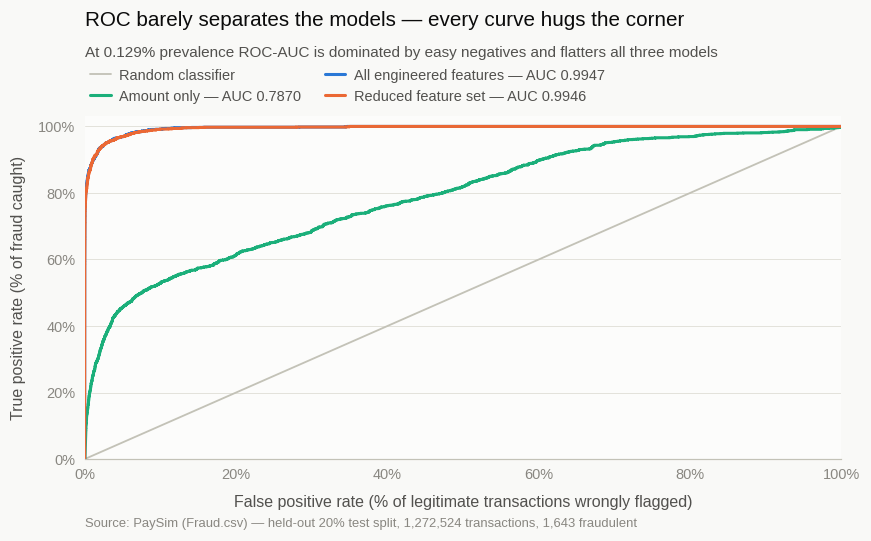

In [22]:
fig, ax = vs.figure()
ax.plot([0, 1], [0, 1], color=vs.AXIS, linewidth=1.2, label="Random classifier")
for name, prob in PROBS.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2.0,
            label=f"{name} — AUC {roc_auc_score(y_test, prob):.4f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.03)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))
pct = vs.FuncFormatter(lambda v, p: f"{v * 100:.0f}%")
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)

vs.finish(
    fig, ax,
    title="ROC barely separates the models — every curve hugs the corner",
    subtitle="At 0.129% prevalence ROC-AUC is dominated by easy negatives and "
             "flatters all three models",
    xlabel="False positive rate (% of legitimate transactions wrongly flagged)",
    ylabel="True positive rate (% of fraud caught)",
    source=MSRC, legend=True, legend_ncol=2,
)
vs.save(fig, "12-roc-curves")
plt.show()


### 4.2 Precision-Recall Curves
With 1 positive per 775 rows, precision-recall is the honest view: it ignores the
1.27M easy negatives and scores only the decisions that matter.


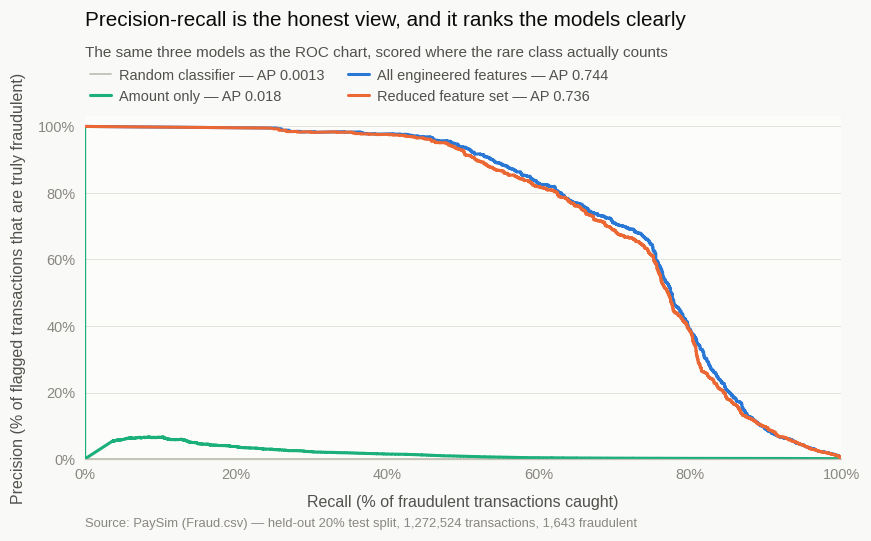

In [23]:
prevalence = float(y_test.mean())

fig, ax = vs.figure()
ax.axhline(prevalence, color=vs.AXIS, linewidth=1.2,
           label=f"Random classifier — AP {prevalence:.4f}")
for name, prob in PROBS.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ax.plot(recall, precision, color=MODEL_COLORS[name], linewidth=2.0,
            label=f"{name} — AP {average_precision_score(y_test, prob):.3f}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.03)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(0, 1, 6))
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)

vs.finish(
    fig, ax,
    title="Precision-recall is the honest view, and it ranks the models clearly",
    subtitle="The same three models as the ROC chart, scored where the rare class "
             "actually counts",
    xlabel="Recall (% of fraudulent transactions caught)",
    ylabel="Precision (% of flagged transactions that are truly fraudulent)",
    source=MSRC, legend=True, legend_ncol=2,
)
vs.save(fig, "13-precision-recall-curves")
plt.show()


### 4.3 What the Model Actually Learned


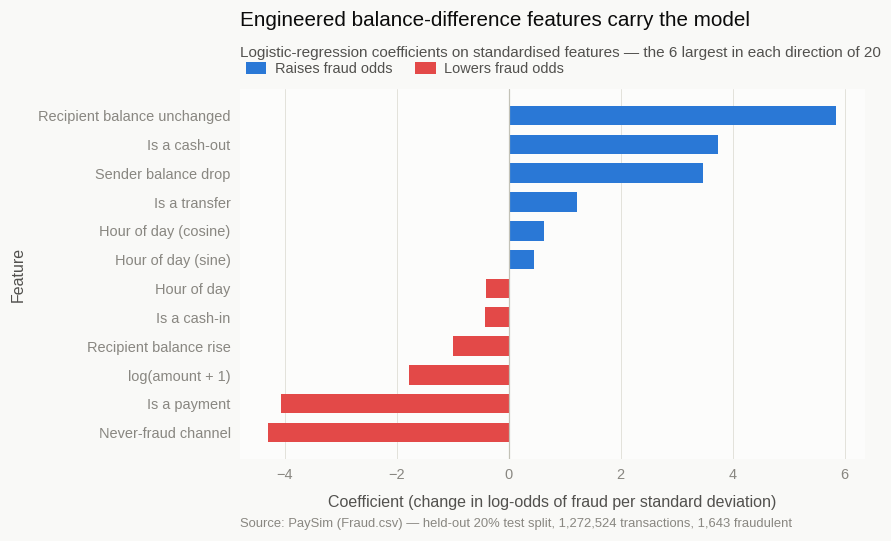

In [24]:
PRETTY = {
    "type_CASH_OUT": "Is a cash-out", "type_TRANSFER": "Is a transfer",
    "type_PAYMENT": "Is a payment", "type_CASH_IN": "Is a cash-in",
    "type_DEBIT": "Is a debit", "suspicious_flag": "Recipient balance unchanged",
    "diff_orig": "Sender balance drop", "diff_dest": "Recipient balance rise",
    "log_amount": "log(amount + 1)", "oldbalanceOrg": "Sender balance before",
    "oldbalanceDest": "Recipient balance before", "newbalanceDest": "Recipient balance after",
    "hour_sin": "Hour of day (sine)", "hour_cos": "Hour of day (cosine)",
    "day_of_week": "Step within week", "always_nonfraud_type": "Never-fraud channel",
    "error_flag": "Negative-balance flag", "amount": "Amount", "hour": "Hour of day",
    "step": "Step",
}

coefficients = COEFS["All engineered features"].sort_values()
top = pd.concat([coefficients.head(6), coefficients.tail(6)])
top.index = [PRETTY.get(i, i) for i in top.index]

fig, ax = vs.figure()
ax.barh(range(len(top)), top.values,
        color=[vs.RED if v < 0 else vs.BLUE for v in top.values], height=0.68)
ax.set_yticks(range(len(top)), top.index)
ax.grid(False)
ax.xaxis.grid(True)
ax.axvline(0, color=vs.AXIS, linewidth=0.8)
ax.spines["bottom"].set_visible(False)

vs.finish(
    fig, ax,
    title="Engineered balance-difference features carry the model",
    subtitle=f"Logistic-regression coefficients on standardised features — the 6 "
             f"largest in each direction of {len(coefficients)}",
    xlabel="Coefficient (change in log-odds of fraud per standard deviation)",
    ylabel="Feature",
    source=MSRC, left=0.265,
)
handles = [plt.Rectangle((0, 0), 1, 1, color=vs.BLUE),
           plt.Rectangle((0, 0), 1, 1, color=vs.RED)]
ax.legend(handles, ["Raises fraud odds", "Lowers fraud odds"], loc="lower left",
          bbox_to_anchor=(0.0, 1.02), ncol=2, frameon=False, fontsize=9.5)

vs.save(fig, "14-model-coefficients")
plt.show()


### 4.4 Confusion Matrix at the Default Threshold


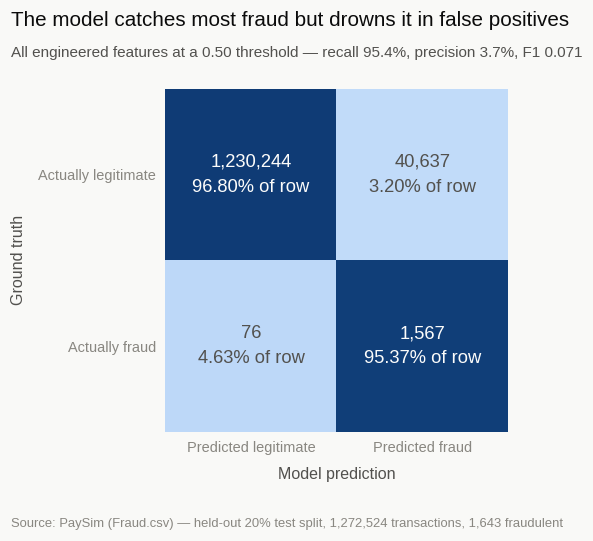

,ROC-AUC,Average precision,Precision,Recall,F1
Model,,,,,
Amount only,0.7870,0.0184,0.0027,0.7243,0.0054
All engineered features,0.9947,0.7440,0.0371,0.9537,0.0715
Reduced feature set,0.9946,0.7355,0.0361,0.9556,0.0696


In [25]:
best_prob = PROBS["All engineered features"]
y_pred = (best_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
cm_row_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = vs.figure()
im = ax.imshow(cm_row_pct, cmap=vs.CMAP_SEQ, vmin=0, vmax=100)
ax.set_xticks([0, 1], ["Predicted legitimate", "Predicted fraud"])
ax.set_yticks([0, 1], ["Actually legitimate", "Actually fraud"])
ax.grid(False)
ax.spines["bottom"].set_visible(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}\n{cm_row_pct[i, j]:.2f}% of row",
                ha="center", va="center", fontsize=12, linespacing=1.6,
                color=vs.SURFACE if cm_row_pct[i, j] > 55 else vs.INK_2)

P = precision_score(y_test, y_pred)
R = recall_score(y_test, y_pred)
F = f1_score(y_test, y_pred)

vs.finish(
    fig, ax,
    title="The model catches most fraud but drowns it in false positives",
    subtitle=f"All engineered features at a 0.50 threshold — recall {R * 100:.1f}%, "
             f"precision {P * 100:.1f}%, F1 {F:.3f}",
    xlabel="Model prediction", ylabel="Ground truth",
    source=MSRC, left=0.235, bottom=0.20,
)
vs.save(fig, "15-confusion-matrix")
plt.show()

summary = pd.DataFrame([
    {"Model": name,
     "ROC-AUC": roc_auc_score(y_test, prob),
     "Average precision": average_precision_score(y_test, prob),
     "Precision": precision_score(y_test, (prob >= 0.5).astype(int)),
     "Recall": recall_score(y_test, (prob >= 0.5).astype(int)),
     "F1": f1_score(y_test, (prob >= 0.5).astype(int))}
    for name, prob in PROBS.items()
]).set_index("Model").round(4)
summary


# Fraud Detection Project Summary

## 1. Data Cleaning
- **Missing values:** none in any column.
- **Outliers:** retained in `amount` — fraudulent transactions *are* the extreme values.
- **Multicollinearity:** dropped `newbalanceOrig` (r = 1.00 with `oldbalanceOrg`). Kept
  both destination balances (r = 0.98, not 1.00) because the gap between them is itself
  the fraud signal.
- **Leakage:** dropped `nameOrig`, `nameDest` and `isFlaggedFraud`.

## 2. Feature Engineering
`diff_orig` and `diff_dest` (balance movements), `suspicious_flag` (money left the
sender but the recipient balance did not move), cyclical hour encodings, one-hot
channel dummies and `log_amount`.

Two engineered features turned out to be dead on this dataset and are dropped from the
reduced model:
- `error_flag` is identically 0 — PaySim contains no negative balances at all, so its
  fitted coefficient is exactly 0.000.
- `always_nonfraud_type` is an exact linear combination of the three never-fraud
  channel dummies, so it adds no information beyond them.

## 3. Model Results (held-out 20% test split)

| Model | ROC-AUC | Avg precision | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Amount only | 0.7870 | 0.0184 | 0.0027 | 0.7243 | 0.0054 |
| All engineered features | 0.9947 | 0.7440 | 0.0371 | 0.9537 | 0.0715 |
| Reduced feature set | 0.9946 | 0.7355 | 0.0361 | 0.9556 | 0.0696 |

## 4. What This Means
ROC-AUC of 0.995 looks close to solved and is misleading: at 0.129% prevalence the
score is dominated by 1.27M easy negatives. Average precision — 0.744 for the
engineered model against 0.0013 for a random one — is the metric that separates the
variants, and the confusion matrix shows the cost: catching 1,567 of 1,643 frauds also
raises **40,637 false positives**, so only 1 alert in 27 is real at the default 0.50
threshold. Feature engineering, not model choice, does the work here: the same
classifier on `log_amount` alone scores AP 0.018.
